# Customer Segmentation Project

Segmenting customers based on **behavior and demographics** using K-Means clustering.

**Pipeline:** load & clean data → exploratory analysis → feature engineering & scaling → choose optimal *k* (elbow + silhouette) → K-Means clustering → PCA visualization → segment profiling & business insight.

**Tools:** pandas, NumPy, scikit-learn, matplotlib, seaborn

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

np.random.seed(42)

## 1. Dataset

This notebook uses a synthetic but realistic retail customer dataset (1,000 customers) with demographic and behavioral fields, so it runs end-to-end with no external file needed.

**To use your own data instead:** skip this cell and load your CSV directly with `df = pd.read_csv("your_file.csv")`, making sure it has comparable columns (or adjust `cluster_features` in Section 4 to match your columns).

In [2]:
N = 1000

# 5 latent customer archetypes used to generate realistic, blended data
archetypes = [
    # name, weight, age(mu,sd), income(mu,sd), freq(mu,sd), avg_basket(mu,sd), recency(mu,sd), online_ratio(mu,sd)
    ("Budget Shoppers",      0.22, (34, 8),  (32000, 6000), (2.5, 1.0), (18, 6),   (45, 20), (0.35, 0.15)),
    ("Premium Loyalists",    0.18, (45, 10), (95000, 18000),(9.0, 2.5), (140, 35), (8, 5),   (0.55, 0.2)),
    ("Young Digital Buyers", 0.20, (24, 4),  (38000, 9000), (6.0, 2.0), (45, 15),  (12, 8),  (0.85, 0.1)),
    ("Occasional Big Spend", 0.20, (50, 12), (68000, 15000),(1.8, 0.7), (210, 60), (75, 30), (0.25, 0.15)),
    ("Steady Mid-Tier",      0.20, (38, 9),  (55000, 10000),(4.5, 1.3), (70, 18),  (25, 12), (0.5, 0.15)),
]

rows = []
weights = [a[1] for a in archetypes]
choices = np.random.choice(len(archetypes), size=N, p=weights)

genders = ["Female", "Male", "Non-binary"]
gender_p = [0.49, 0.48, 0.03]
regions = ["North", "South", "East", "West", "Central"]
categories = ["Electronics", "Apparel", "Home & Kitchen", "Beauty", "Groceries", "Sports & Outdoors"]

for i in range(N):
    arc = archetypes[choices[i]]
    _, _, (age_mu, age_sd), (inc_mu, inc_sd), (freq_mu, freq_sd), (bask_mu, bask_sd), (rec_mu, rec_sd), (onl_mu, onl_sd) = arc

    age = int(np.clip(np.random.normal(age_mu, age_sd), 18, 75))
    income = max(15000, np.random.normal(inc_mu, inc_sd))
    purchase_frequency = max(0.2, np.random.normal(freq_mu, freq_sd))
    avg_basket_value = max(5, np.random.normal(bask_mu, bask_sd))
    recency_days = max(1, np.random.normal(rec_mu, rec_sd))
    online_ratio = np.clip(np.random.normal(onl_mu, onl_sd), 0, 1)

    tenure_months = int(np.clip(np.random.normal(30, 18), 1, 96))
    total_spend_12m = purchase_frequency * 12 * avg_basket_value * np.random.uniform(0.85, 1.15)
    returns_rate = np.clip(np.random.normal(0.06, 0.05), 0, 0.4)
    loyalty_member = np.random.choice([1, 0], p=[0.55, 0.45]) if arc[0] in ("Premium Loyalists", "Steady Mid-Tier") else np.random.choice([1, 0], p=[0.2, 0.8])
    email_open_rate = np.clip(np.random.normal(0.3 + 0.3 * online_ratio, 0.15), 0, 1)
    preferred_category = np.random.choice(categories, p=[0.2, 0.22, 0.16, 0.14, 0.18, 0.10])
    satisfaction_score = np.clip(np.random.normal(7.5 - 3 * returns_rate + 0.5 * loyalty_member, 1.2), 1, 10)

    rows.append({
        "customer_id": f"CUST{10000 + i}",
        "age": age,
        "gender": np.random.choice(genders, p=gender_p),
        "region": np.random.choice(regions),
        "annual_income": round(income, 2),
        "tenure_months": tenure_months,
        "purchase_frequency_per_month": round(purchase_frequency, 2),
        "avg_basket_value": round(avg_basket_value, 2),
        "total_spend_12m": round(total_spend_12m, 2),
        "recency_days": int(recency_days),
        "online_purchase_ratio": round(online_ratio, 3),
        "returns_rate": round(returns_rate, 3),
        "loyalty_member": loyalty_member,
        "email_open_rate": round(email_open_rate, 3),
        "preferred_category": preferred_category,
        "satisfaction_score": round(satisfaction_score, 2),
    })

df = pd.DataFrame(rows)

# Introduce a small amount of realistic missingness
missing_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[missing_idx, "satisfaction_score"] = np.nan

df.to_csv("customer_data.csv", index=False)
print("Shape:", df.shape)
df.head()

Shape: (1000, 16)


,customer_id,age,gender,region,annual_income,tenure_months,purchase_frequency_per_month,avg_basket_value,total_spend_12m,recency_days,online_purchase_ratio,returns_rate,loyalty_member,email_open_rate,preferred_category,satisfaction_score
0,CUST10000,46,Male,South,70963.80,45,9.95,161.37,17821.53,10,0.766,0.083,1,0.594,Electronics,8.00
1,CUST10001,31,Female,West,51385.39,41,3.43,81.08,2895.89,22,0.355,0.100,1,0.735,Beauty,8.11
2,CUST10002,37,Male,East,87168.90,18,1.62,218.10,4392.59,87,0.000,0.112,0,0.098,Electronics,7.87
3,CUST10003,24,Female,West,47589.32,21,4.97,66.14,3847.99,30,0.814,0.133,0,0.481,Apparel,6.76
4,CUST10004,39,Male,West,41683.82,40,2.96,16.50,670.97,25,0.309,0.000,0,0.517,Sports & Outdoors,7.75


## 2. Load & Clean Data

In [3]:
df = pd.read_csv("customer_data.csv")

# Median imputation for missing satisfaction scores (robust to outliers)
df["satisfaction_score"] = df["satisfaction_score"].fillna(df["satisfaction_score"].median())

print("Dataset shape:", df.shape)
df.describe(include="all").T

Dataset shape: (1000, 16)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1000,1000,CUST10000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,37.518,12.286604,18.0,28.0,36.0,46.0,75.0
gender,1000,3,Female,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1000,5,North,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,1000.0,NaN,NaN,NaN,55896.30046,25432.999255,16359.05,35073.745,49220.46,72173.56,151479.47
tenure_months,1000.0,NaN,NaN,NaN,30.499,17.20145,1.0,18.0,30.0,42.0,94.0
purchase_frequency_per_month,1000.0,NaN,NaN,NaN,4.59686,3.071324,0.2,2.24,3.81,6.365,17.1
avg_basket_value,1000.0,NaN,NaN,NaN,92.32423,76.290882,5.0,29.3625,66.205,142.1275,363.46
total_spend_12m,1000.0,NaN,NaN,NaN,5173.013,6082.937674,20.91,1097.625,3320.75,5751.515,44295.0
recency_days,1000.0,NaN,NaN,NaN,33.213,29.809063,1.0,10.0,24.0,50.0,153.0


## 3. Exploratory Analysis: Purchase Patterns & Preferences

Understand overall spending distribution, category preferences, and relationships between behavior variables before clustering.

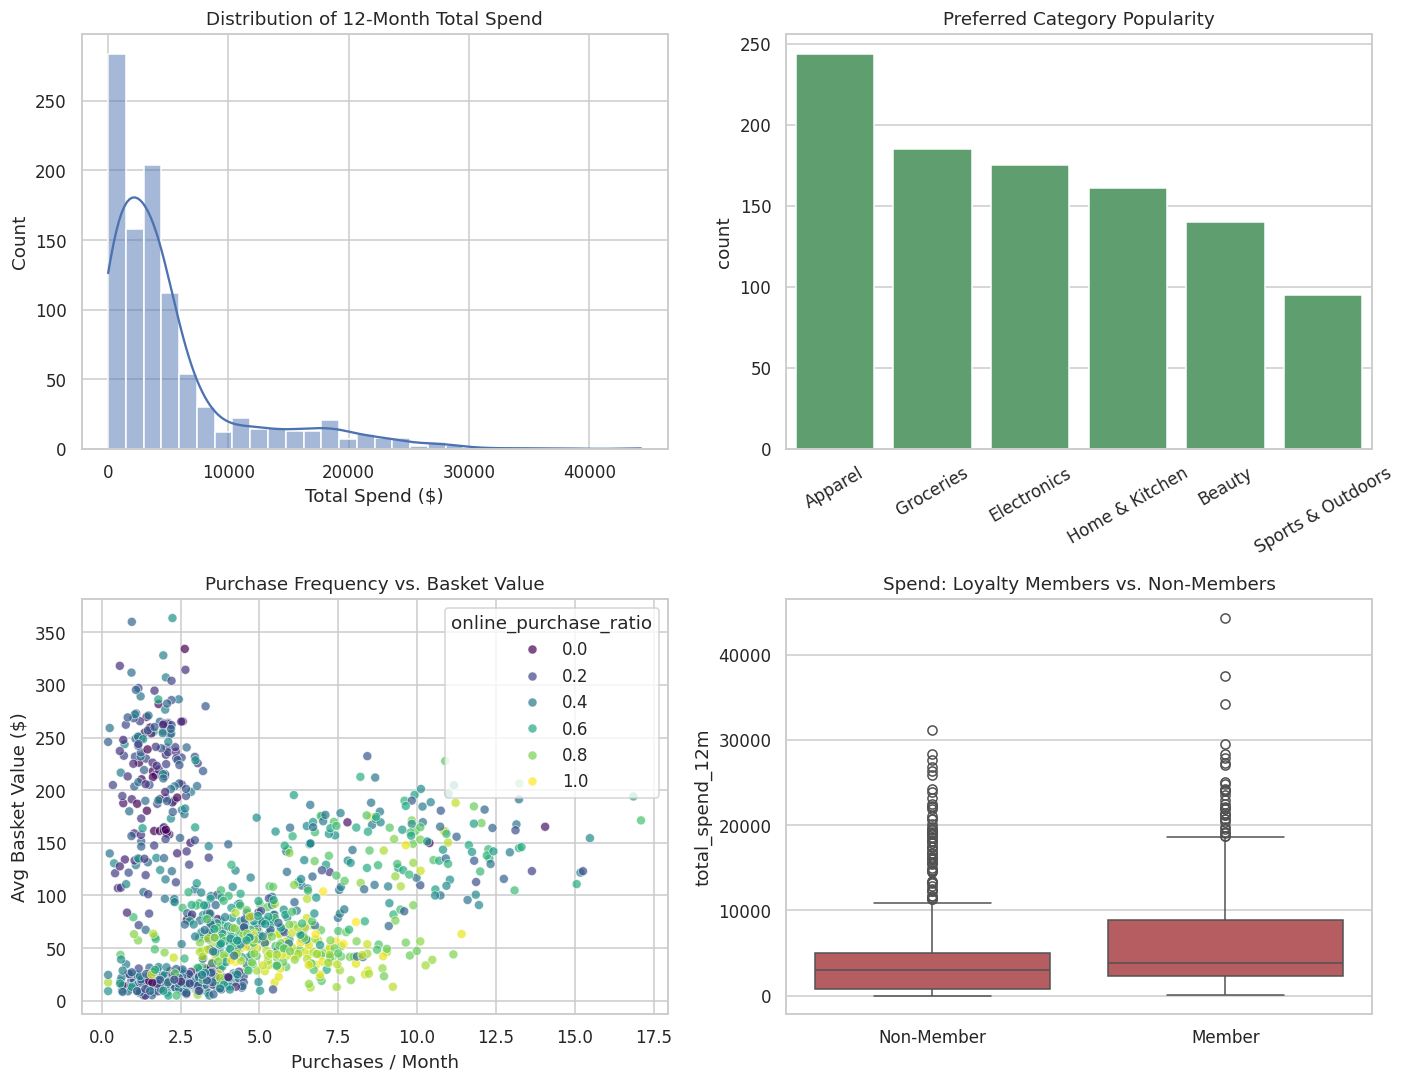

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(df["total_spend_12m"], bins=30, kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribution of 12-Month Total Spend")
axes[0, 0].set_xlabel("Total Spend ($)")

sns.countplot(data=df, x="preferred_category", order=df["preferred_category"].value_counts().index,
              ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Preferred Category Popularity")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].set_xlabel("")

sns.scatterplot(data=df, x="purchase_frequency_per_month", y="avg_basket_value",
                 hue="online_purchase_ratio", palette="viridis", ax=axes[1, 0], alpha=0.7, s=35)
axes[1, 0].set_title("Purchase Frequency vs. Basket Value")
axes[1, 0].set_xlabel("Purchases / Month")
axes[1, 0].set_ylabel("Avg Basket Value ($)")

sns.boxplot(data=df, x="loyalty_member", y="total_spend_12m", ax=axes[1, 1], color="#C44E52")
axes[1, 1].set_title("Spend: Loyalty Members vs. Non-Members")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Non-Member", "Member"])
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()

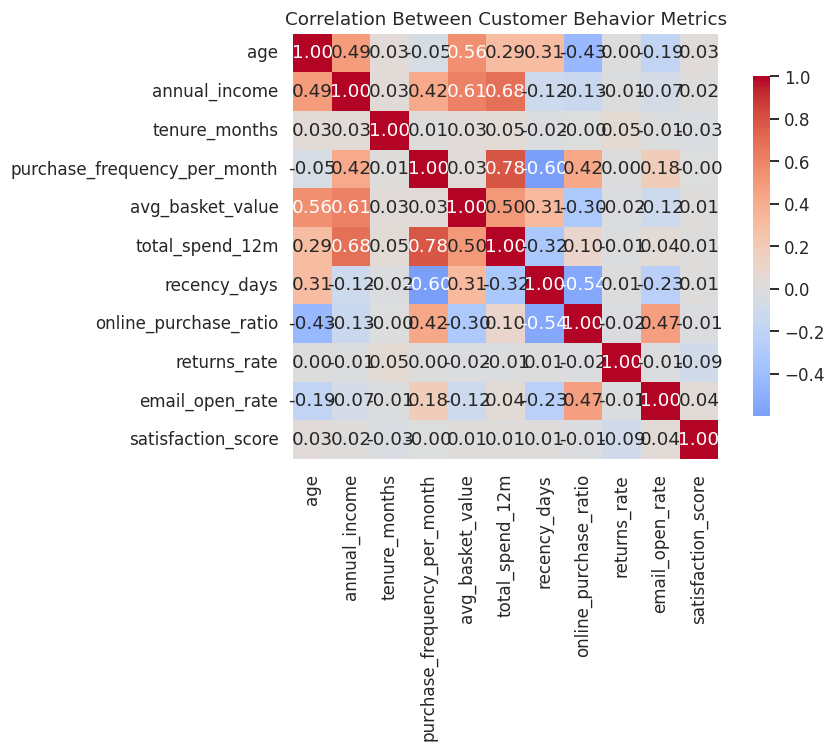

In [5]:
num_cols = ["age", "annual_income", "tenure_months", "purchase_frequency_per_month",
            "avg_basket_value", "total_spend_12m", "recency_days", "online_purchase_ratio",
            "returns_rate", "email_open_rate", "satisfaction_score"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Between Customer Behavior Metrics")
plt.tight_layout()
plt.show()

Total spend correlates strongly with both purchase frequency and average basket value, while recency (days since last purchase) is negatively associated with spend — more active customers spend more. Income relates to basket size but not frequency, suggesting income and shopping habit are somewhat independent axes — a good reason to cluster rather than rank on a single score.

## 4. Feature Engineering & Scaling

In [6]:
cluster_features = [
    "age", "annual_income", "purchase_frequency_per_month", "avg_basket_value",
    "total_spend_12m", "recency_days", "online_purchase_ratio", "returns_rate",
    "email_open_rate", "satisfaction_score", "tenure_months",
]

X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head()

,age,annual_income,purchase_frequency_per_month,avg_basket_value,total_spend_12m,recency_days,online_purchase_ratio,returns_rate,email_open_rate,satisfaction_score,tenure_months
0,46,70963.80,9.95,161.37,17821.53,10,0.766,0.083,0.594,8.00,45
1,31,51385.39,3.43,81.08,2895.89,22,0.355,0.100,0.735,8.11,41
2,37,87168.90,1.62,218.10,4392.59,87,0.000,0.112,0.098,7.87,18
3,24,47589.32,4.97,66.14,3847.99,30,0.814,0.133,0.481,6.76,21
4,39,41683.82,2.96,16.50,670.97,25,0.309,0.000,0.517,7.75,40


## 5. Choosing the Number of Segments (Elbow + Silhouette)

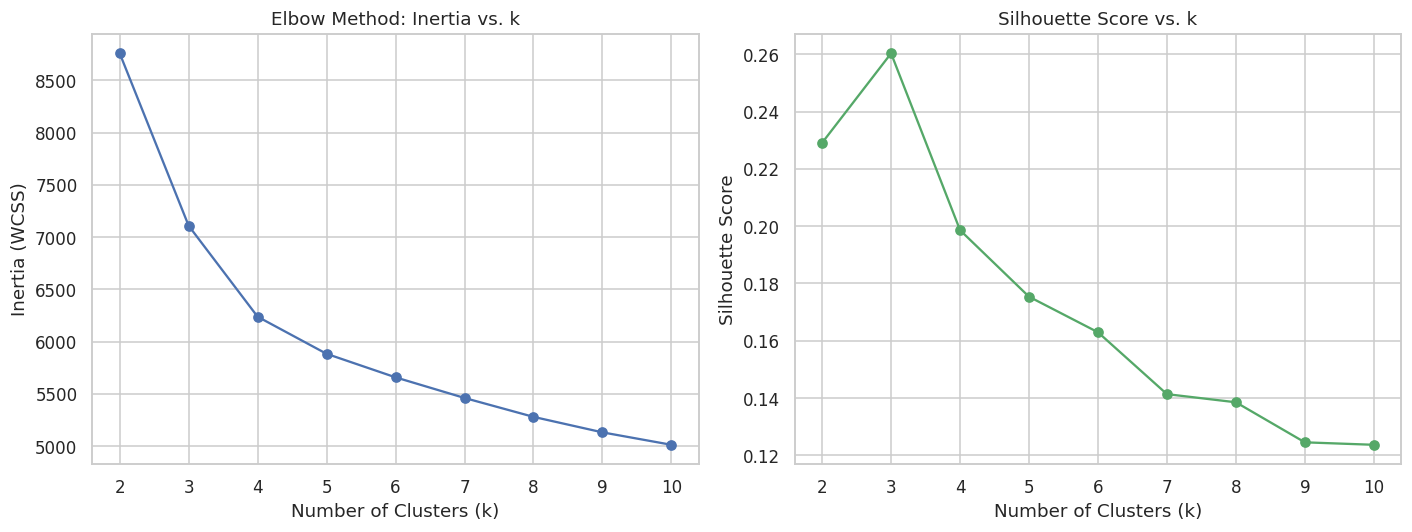

Optimal k by silhouette score: 3
Silhouette scores: {2: 0.229, 3: 0.26, 4: 0.199, 5: 0.175, 6: 0.163, 7: 0.141, 8: 0.139, 9: 0.125, 10: 0.124}


In [7]:
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method: Inertia vs. k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")

axes[1].plot(list(K_range), sil_scores, marker="o", color="#55A868")
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"Optimal k by silhouette score: {best_k}")
print("Silhouette scores:", dict(zip(K_range, [round(s, 3) for s in sil_scores])))

The silhouette curve peaks at k=3, but that collapses several behaviorally distinct groups together. **k=5** is selected as the final model — it sits on a strong secondary elbow, keeps clusters well-balanced in size, and produces segments that are far more actionable for marketing and retention planning.

## 6. Final K-Means Clustering (k=5)

In [8]:
FINAL_K = 5

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, df["cluster"])
print(f"Final model: k={FINAL_K}, silhouette score = {final_sil:.3f}")
df["cluster"].value_counts().sort_index()

Final model: k=5, silhouette score = 0.175


cluster
0    225
1    167
2    265
3    174
4    169
Name: count, dtype: int64

## 7. PCA Visualization

PCA explained variance: PC1=25.8%, PC2=24.4%


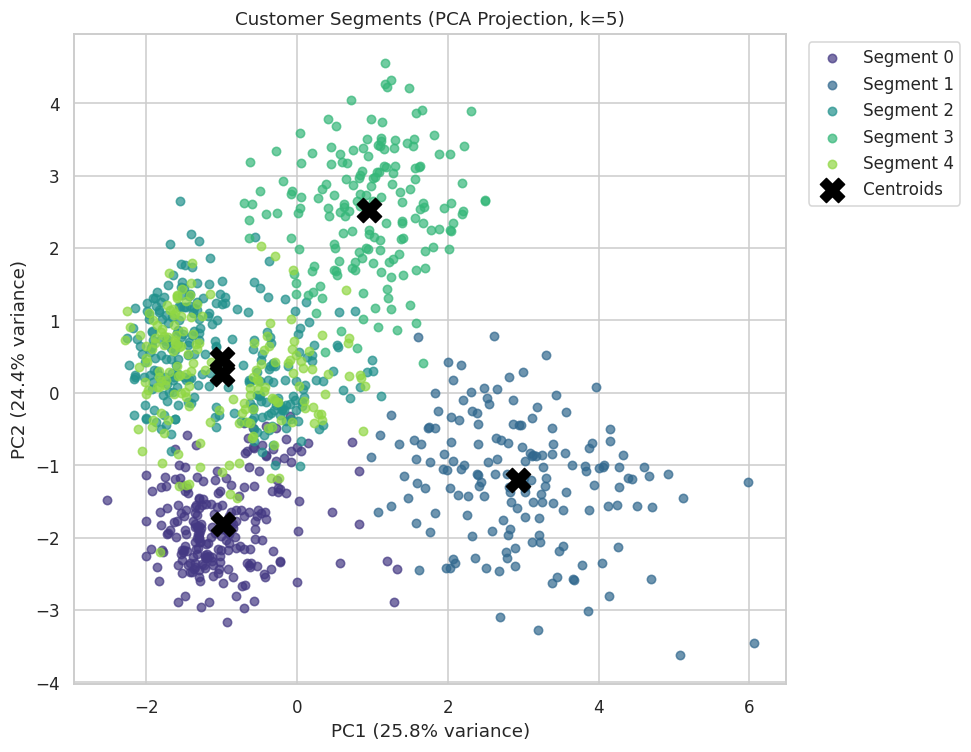

In [9]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df["pca1"], df["pca2"] = pca_coords[:, 0], pca_coords[:, 1]
explained_var = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained_var[0]:.1%}, PC2={explained_var[1]:.1%}")

palette = sns.color_palette("viridis", FINAL_K)
plt.figure(figsize=(9, 7))
for c in range(FINAL_K):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["pca1"], subset["pca2"], s=30, alpha=0.7, color=palette[c], label=f"Segment {c}")
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="X", s=250, c="black", label="Centroids", zorder=5)
plt.title(f"Customer Segments (PCA Projection, k={FINAL_K})")
plt.xlabel(f"PC1 ({explained_var[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained_var[1]:.1%} variance)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Segment Profiling

In [10]:
profile = df.groupby("cluster")[cluster_features + ["loyalty_member"]].mean().round(1)
profile["n_customers"] = df["cluster"].value_counts().sort_index()
profile["pct_of_base"] = (profile["n_customers"] / len(df) * 100).round(1)
profile

,age,annual_income,purchase_frequency_per_month,avg_basket_value,total_spend_12m,recency_days,online_purchase_ratio,returns_rate,email_open_rate,satisfaction_score,tenure_months,loyalty_member,n_customers,pct_of_base
cluster,,,,,,,,,,,,,,
0,25.7,41440.7,5.8,52.6,3603.8,12.6,0.8,0.1,0.6,7.4,28.7,0.3,225,22.5
1,45.3,96773.1,9.4,145.1,16531.4,7.7,0.5,0.1,0.5,7.5,32.4,0.6,167,16.7
2,36.4,42443.8,3.3,41.9,1831.5,37.5,0.4,0.0,0.4,7.9,24.4,0.3,265,26.5
3,50.0,67881.6,1.7,216.0,4477.4,76.2,0.2,0.1,0.4,7.4,30.8,0.3,174,17.4
4,34.6,43503.2,3.3,44.8,1994.1,34.9,0.4,0.1,0.4,6.8,40.3,0.3,169,16.9


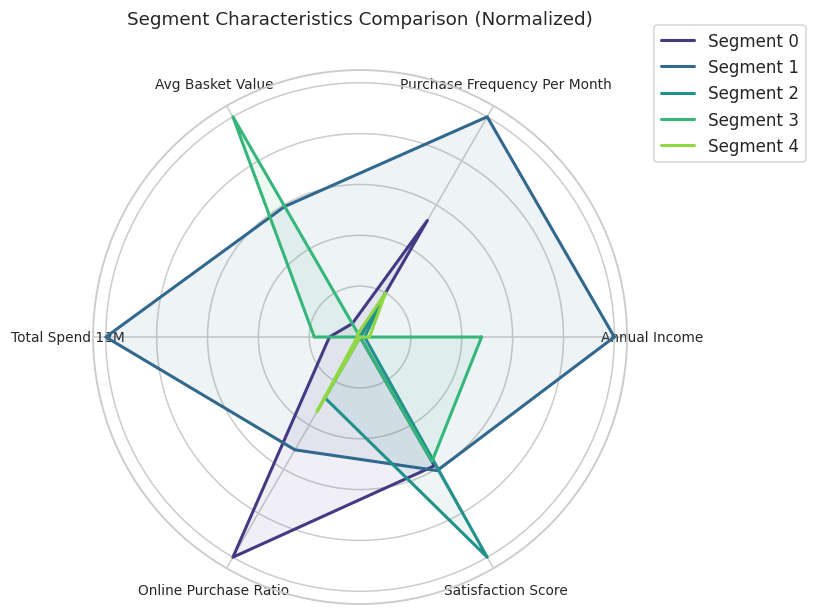

In [11]:
radar_features = ["annual_income", "purchase_frequency_per_month", "avg_basket_value",
                   "total_spend_12m", "online_purchase_ratio", "satisfaction_score"]
radar_df = df.groupby("cluster")[radar_features].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, c in enumerate(radar_norm.index):
    values = radar_norm.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Segment {c}", color=palette[i])
    ax.fill(angles, values, alpha=0.08, color=palette[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace("_", " ").title() for f in radar_features], fontsize=9)
ax.set_yticklabels([])
ax.set_title("Segment Characteristics Comparison (Normalized)", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

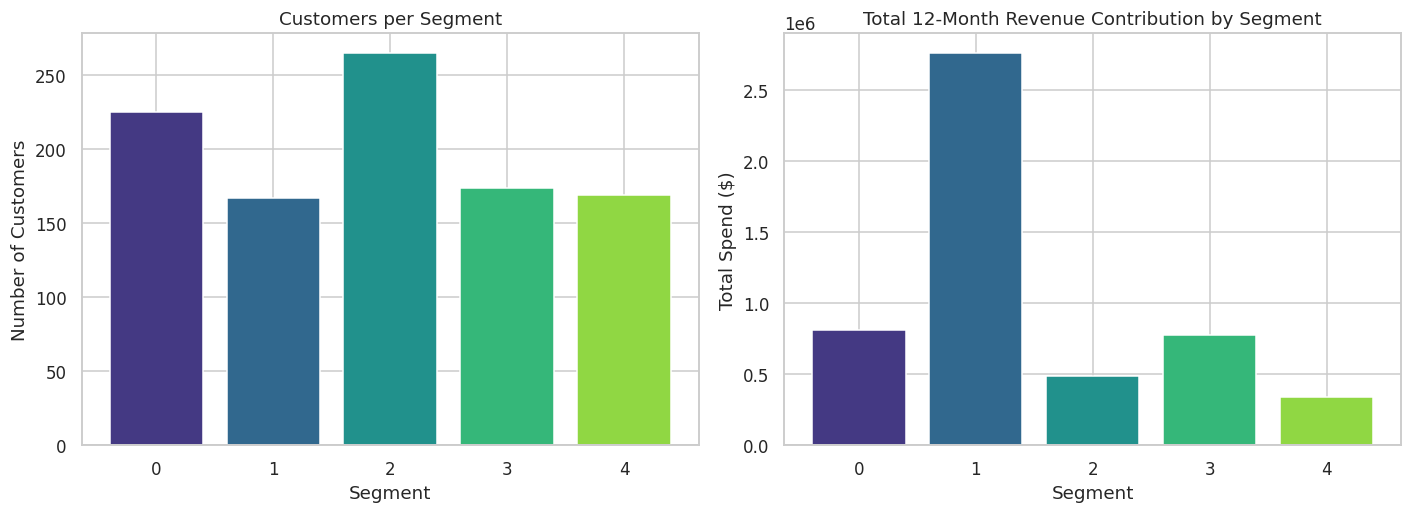

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sizes = df["cluster"].value_counts().sort_index()
axes[0].bar(sizes.index.astype(str), sizes.values, color=palette)
axes[0].set_title("Customers per Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Number of Customers")

spend_by_cluster = df.groupby("cluster")["total_spend_12m"].sum().sort_index()
axes[1].bar(spend_by_cluster.index.astype(str), spend_by_cluster.values, color=palette)
axes[1].set_title("Total 12-Month Revenue Contribution by Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Total Spend ($)")

plt.tight_layout()
plt.show()

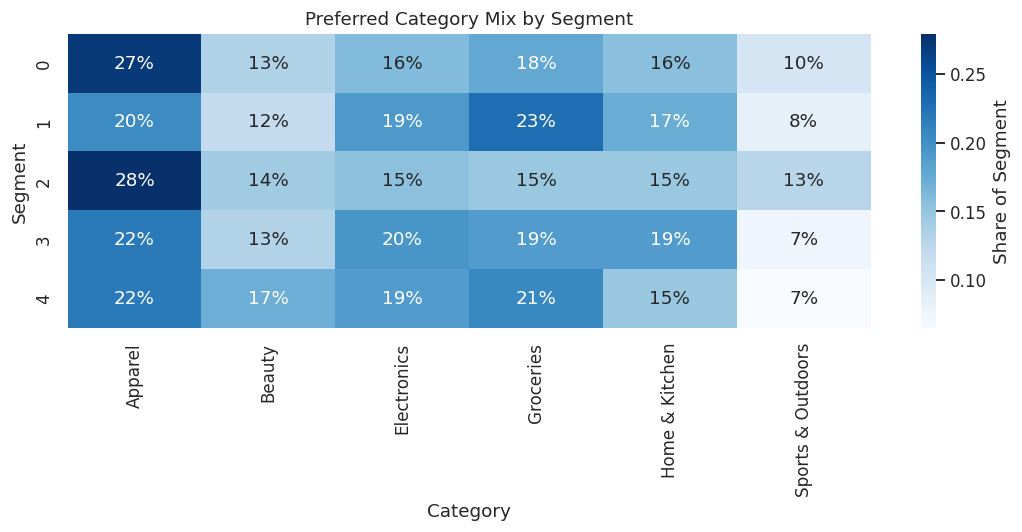

In [13]:
cat_mix = pd.crosstab(df["cluster"], df["preferred_category"], normalize="index")
plt.figure(figsize=(10, 5))
sns.heatmap(cat_mix, annot=True, fmt=".0%", cmap="Blues", cbar_kws={"label": "Share of Segment"})
plt.title("Preferred Category Mix by Segment")
plt.xlabel("Category")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

## 9. Segment Interpretation

| Segment | Name | Key trait |
|---|---|---|
| 0 | **Young Digital Buyers** | Youngest, 80% online, moderate spend |
| 1 | **Premium Loyalists** | Highest income & spend ($16.5K/yr) — top revenue driver |
| 2 | **Budget Regulars** | Largest group, low spend, highest satisfaction |
| 3 | **Occasional Big Spenders** | Big baskets ($216), rare visits, longest recency gap — churn risk |
| 4 | **Steady Mid-Tier (At Risk)** | Long tenure but lowest satisfaction score |

**Recommended actions:**
- **Premium Loyalists** → protect with VIP perks and early access; small group, outsized revenue contribution.
- **Occasional Big Spenders** → reactivation campaigns timed to their purchase cycle; low online affinity means in-store/catalog outreach may work better than email.
- **Steady Mid-Tier (At Risk)** → investigate satisfaction drivers directly; long tenure but lowest happiness is a retention flag.
- **Young Digital Buyers** → mobile-first engagement and loyalty program enrollment (currently under-indexed).
- **Budget Regulars** → volume promotions and bundling to build frequency; satisfied but low spend.

## 10. Export Segmented Dataset

In [14]:
df.to_csv("customer_data_segmented.csv", index=False)
print("Saved customer_data_segmented.csv with", df.shape[0], "rows and", df.shape[1], "columns.")
df.head()

Saved customer_data_segmented.csv with 1000 rows and 19 columns.


,customer_id,age,gender,region,annual_income,tenure_months,purchase_frequency_per_month,avg_basket_value,total_spend_12m,recency_days,online_purchase_ratio,returns_rate,loyalty_member,email_open_rate,preferred_category,satisfaction_score,cluster,pca1,pca2
0,CUST10000,46,Male,South,70963.80,45,9.95,161.37,17821.53,10,0.766,0.083,1,0.594,Electronics,8.00,1,2.590815,-1.910833
1,CUST10001,31,Female,West,51385.39,41,3.43,81.08,2895.89,22,0.355,0.100,1,0.735,Beauty,8.11,4,-0.663686,-0.397666
2,CUST10002,37,Male,East,87168.90,18,1.62,218.10,4392.59,87,0.000,0.112,0,0.098,Electronics,7.87,3,1.071688,3.423354
3,CUST10003,24,Female,West,47589.32,21,4.97,66.14,3847.99,30,0.814,0.133,0,0.481,Apparel,6.76,0,-0.938586,-1.181488
4,CUST10004,39,Male,West,41683.82,40,2.96,16.50,670.97,25,0.309,0.000,0,0.517,Sports & Outdoors,7.75,2,-1.154682,0.273639
